# Encontro 2 — Abrir o registro e rodar a RCA

**De onde viemos:** no Encontro 1 a leitura do painel apontou a **Serra-02** como
problema (líder isolado do Pareto + tendência de subida + viés de turno). Agora
formalizamos: **abrimos o registro de problema** e conduzimos a **análise de
causa-raiz (RCA)** ancorada na evidência — sem chutar a causa antes de olhar o dado.

**Você vai praticar:**
1. **Gatilho** — quando um achado vira registro de problema (proativo vs reativo).
2. **5 Porquês** — cada "porquê" preso a uma evidência do dado, não a opinião.
3. **Ishikawa (6 M)** — organizar as hipóteses e destacar as **sustentadas por dados**.
4. **RCA documentada** — problema · evidências · causa-raiz provável · causas afastadas · ação.

## Da fábrica para a TI (e para o laboratório de ensaios)

A régua é a mesma; muda só o vocabulário. A coluna **→ Laboratório de ensaios** mostra a
tradução para o setor-alvo deste material (life sciences / ensaios analíticos).

| Chão de fábrica | TI / ITIL 4 | → Laboratório de ensaios |
|---|---|---|
| Ocorrência (parada, refugo, retrabalho) | **Incidente** | Resultado inválido / amostra para reanálise |
| Máquina que gera refugo recorrente | **Problema** | Instrumento/método/LIMS com reanálise sistemática |
| Reapertar / recalibrar todo turno | **Workaround** | Recalibrar/repetir a cada lote para liberar o laudo |
| Causa identificada + contorno documentado | **Known Error** (KEDB) | Known Error do método/instrumento documentado |
| Manutenção preventiva / padrão de calibração | **Solução permanente** | Calibração/validação de método padronizada |
| Refugo e retrabalho (R$) | **Impacto de negócio** | TAT/SLA e taxa de reanálise (custo + atraso) |

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import plotly.io as pio

# Para INTERATIVO na sessão ao vivo: pio.renderers.default = "notebook"
pio.renderers.default = "png"
pio.templates.default = "plotly_white"

df = pd.read_csv("../data/ocorrencias.csv", parse_dates=["aberto_em", "resolvido_em"])
serra = df[df.maquina == "Serra-02"].copy()
print(f"Serra-02: {len(serra)} ocorrências no período")

Serra-02: 99 ocorrências no período


In [2]:
# SETOR_ALVO parametriza SÓ os exemplos de tradução fábrica->setor (e o mock do Encontro 3).
# Troque o rótulo aqui e nada mais muda: dados, análise e gráficos seguem iguais.
SETOR_ALVO = "laboratorios-de-ensaios"

TRADUCAO_SETOR = {
    "generico": {
        "label": "service desk de TI (genérico)",
        "serra02": "a causa-raiz recorrente por trás de vários chamados",
        "coladeira01": "uma falha intermitente que reincide toda semana",
        "vies_turno": "concentração num turno/equipe específicos",
        "refugo": "retrabalho e reabertura de tickets",
        "metrica": "volume de incidentes recorrentes e MTTR/SLA",
        "distrator": "um incidente Crítico isolado (ex.: queda única) — não é problema",
    },
    "laboratorios-de-ensaios": {
        "label": "laboratório de ensaios analíticos / life sciences",
        "serra02": "instrumento/método analítico (ou módulo do LIMS) que gera resultados "
                   "inválidos e força reanálise de forma sistemática — abre-se problem record "
                   "do componente",
        "coladeira01": "falha intermitente recorrente numa integração de equipamento "
                       "(perda de dados ~semanal)",
        "vies_turno": "concentração num turno/lote/laboratório específico da rede -> "
                      "pista de método/calibração/treino",
        "refugo": "reanálise/repetição de amostras (custo + atraso no resultado)",
        "metrica": "TAT (turnaround time) das amostras e/ou taxa de reanálise "
                   "(mapeia direto para MTTR/SLA)",
        "distrator": "um incidente Crítico isolado (ex.: queda de energia num laboratório) — "
                     "alta gravidade, mas não é problema",
    },
    # Adicione seu setor com as MESMAS chaves para reaproveitar a camada de tradução.
}
ex = TRADUCAO_SETOR.get(SETOR_ALVO, TRADUCAO_SETOR["generico"])
print(f"Setor-alvo dos exemplos: {SETOR_ALVO}  ({ex['label']})")
print(f"  Serra-02 (defeito sistemático) -> {ex['serra02']}")
print(f"  Coladeira-01 (recorrência sutil) -> {ex['coladeira01']}")
print(f"  Viés do turno Noite -> {ex['vies_turno']}")
print(f"  Refugo/retrabalho -> {ex['refugo']}")

Setor-alvo dos exemplos: laboratorios-de-ensaios  (laboratório de ensaios analíticos / life sciences)
  Serra-02 (defeito sistemático) -> instrumento/método analítico (ou módulo do LIMS) que gera resultados inválidos e força reanálise de forma sistemática — abre-se problem record do componente
  Coladeira-01 (recorrência sutil) -> falha intermitente recorrente numa integração de equipamento (perda de dados ~semanal)
  Viés do turno Noite -> concentração num turno/lote/laboratório específico da rede -> pista de método/calibração/treino
  Refugo/retrabalho -> reanálise/repetição de amostras (custo + atraso no resultado)


## 1. Gatilho — quando abrir um registro de problema

Há dois gatilhos clássicos:

- **Reativo** — um incidente grave (ou um grupo deles) já machucou a operação e alguém
  manda investigar a causa. Você corre atrás do prejuízo.
- **Proativo** — a **análise de tendência** mostra degradação *antes* de virar crise.
  Foi o que aconteceu no Encontro 1: a Serra-02 não teve um P1 estrondoso, ela
  **sangrou refugo numa rampa crescente**. Abrir o registro agora é Problem Management
  proativo — o tipo que diferencia um analista sênior.

Vamos reconfirmar a evidência que justifica o registro.

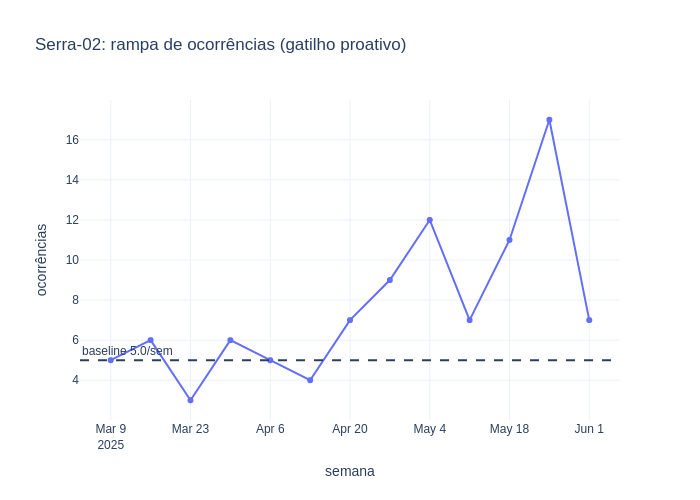

Baseline 4 primeiras semanas: 5.0/sem | Últimas 4: 10.5/sem (+110%)


In [3]:
semanal = serra.set_index("aberto_em").resample("W").size().reset_index(name="ocorrencias")
baseline = semanal.ocorrencias.iloc[:4].mean()
recentes = semanal.ocorrencias.iloc[-4:].mean()

fig = px.line(semanal, x="aberto_em", y="ocorrencias", markers=True,
              title="Serra-02: rampa de ocorrências (gatilho proativo)")
fig.add_hline(y=baseline, line_dash="dash",
              annotation_text=f"baseline {baseline:.1f}/sem", annotation_position="top left")
fig.update_layout(xaxis_title="semana", yaxis_title="ocorrências")
fig.show()
print(f"Baseline 4 primeiras semanas: {baseline:.1f}/sem | Últimas 4: {recentes:.1f}/sem "
      f"(+{(recentes/baseline-1)*100:.0f}%)")

**Registro de problema aberto.** Título sugerido: *"Refugo crescente por corte fora
de medida na Serra-02"*. Próximo passo: investigar a causa **sobre a evidência**.

## 2. Deixe o dado sugerir a hipótese — o recorte por turno

Antes de teorizar, pergunte ao dado **onde** o problema se concentra. A Serra-02 opera
nos três turnos; o refugo está distribuído por igual?

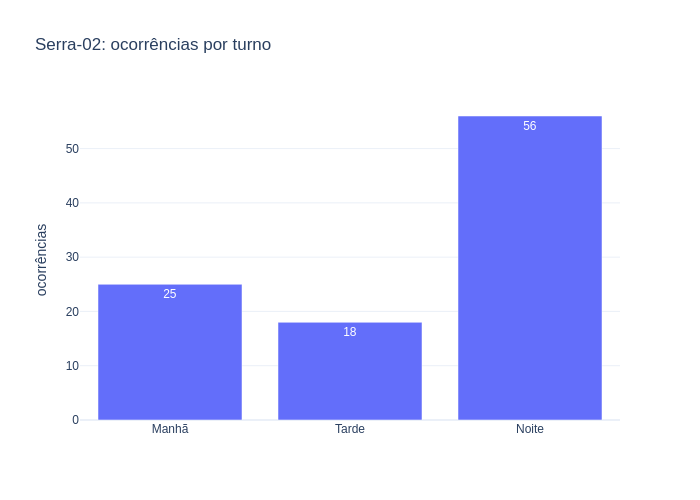

Fração no turno da Noite: 57%


In [4]:
por_turno = (serra.turno.value_counts()
             .reindex(["Manhã", "Tarde", "Noite"]).reset_index())
por_turno.columns = ["turno", "ocorrencias"]
fig = px.bar(por_turno, x="turno", y="ocorrencias", text="ocorrencias",
             title="Serra-02: ocorrências por turno")
fig.update_layout(xaxis_title="", yaxis_title="ocorrências")
fig.show()
frac_noite = (serra.turno == "Noite").mean()
print(f"Fração no turno da Noite: {frac_noite:.0%}")

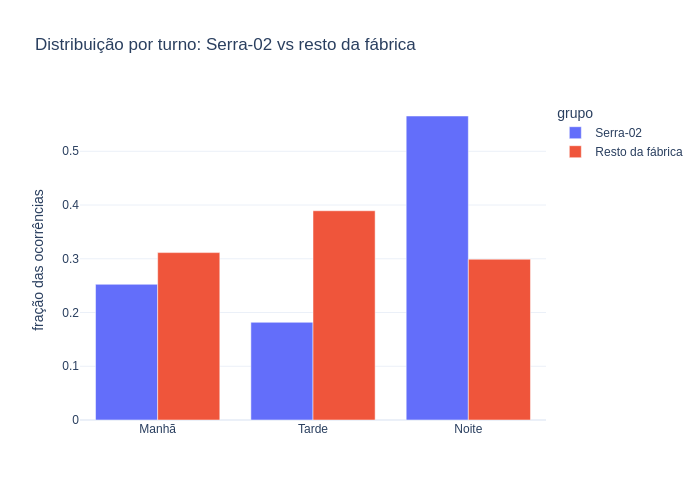

In [5]:
# O viés noturno é específico da Serra-02 ou é o padrão da fábrica inteira?
resto = df[df.maquina != "Serra-02"]
comp = pd.DataFrame({
    "Serra-02": serra.turno.value_counts(normalize=True),
    "Resto da fábrica": resto.turno.value_counts(normalize=True),
}).reindex(["Manhã", "Tarde", "Noite"]).reset_index().melt(
    id_vars="turno", var_name="grupo", value_name="fração")
fig = px.bar(comp, x="turno", y="fração", color="grupo", barmode="group",
             title="Distribuição por turno: Serra-02 vs resto da fábrica")
fig.update_layout(xaxis_title="", yaxis_title="fração das ocorrências")
fig.show()

**Leia os gráficos:** o resto da fábrica reparte o volume de forma ~equilibrada
entre turnos; a Serra-02 **concentra na Noite (~55%)**. O viés é *específico* da máquina
e do turno — não é só "a fábrica produz mais à noite". Isso é uma **pista de causa-raiz**,
não a causa: aponta para algo que muda no terceiro turno (método, supervisão, iluminação).

## 3. Os 5 Porquês — cada porquê preso a uma evidência

A regra de ouro: nenhum "porquê" pode ser opinião. Cada degrau aponta para um dado ou
para uma verificação concreta a fazer no chão de fábrica.

| # | Pergunta | Resposta (ancorada em evidência) |
|---|---|---|
| 1 | Por que há refugo crescente na Serra-02? | Cortes saindo **fora da medida** — mesma assinatura, volume subindo semana a semana (gráfico da rampa). |
| 2 | Por que os cortes saem fora de medida? | A regulagem/esquadro da máquina **desvia ao longo do turno** — verificável medindo peças no início vs fim do turno. |
| 3 | Por que o desvio não é corrigido a tempo? | O desvio **se concentra no turno da Noite** (~55% das ocorrências), quando a conferência dimensional é mais rara. |
| 4 | Por que a conferência falha à noite? | Hipótese: **menos supervisão + iluminação pior + operador menos treinado** no 3º turno — fatores de Método/Mão de obra/Meio ambiente. |
| 5 | Por que esses fatores persistem? | Não há **padrão de calibração por turno** nem checagem dimensional obrigatória — a causa-raiz é de **processo**, não de uma peça quebrada. |

> Note: o Porquê nº 4 ainda é **hipótese a confirmar** com os operadores e a manutenção.
> A RCA aponta a direção certa; a confirmação vem da conversa + verificação no chão.

## 4. Ishikawa (6 M) — organizar e destacar o que o dado sustenta

A espinha-de-peixe organiza as hipóteses em seis famílias (**Máquina, Método, Material,
Mão de obra, Medição, Meio ambiente**). Marcamos com **★** as ramificações que **a
evidência já sustenta** — as outras ficam como hipóteses a testar.

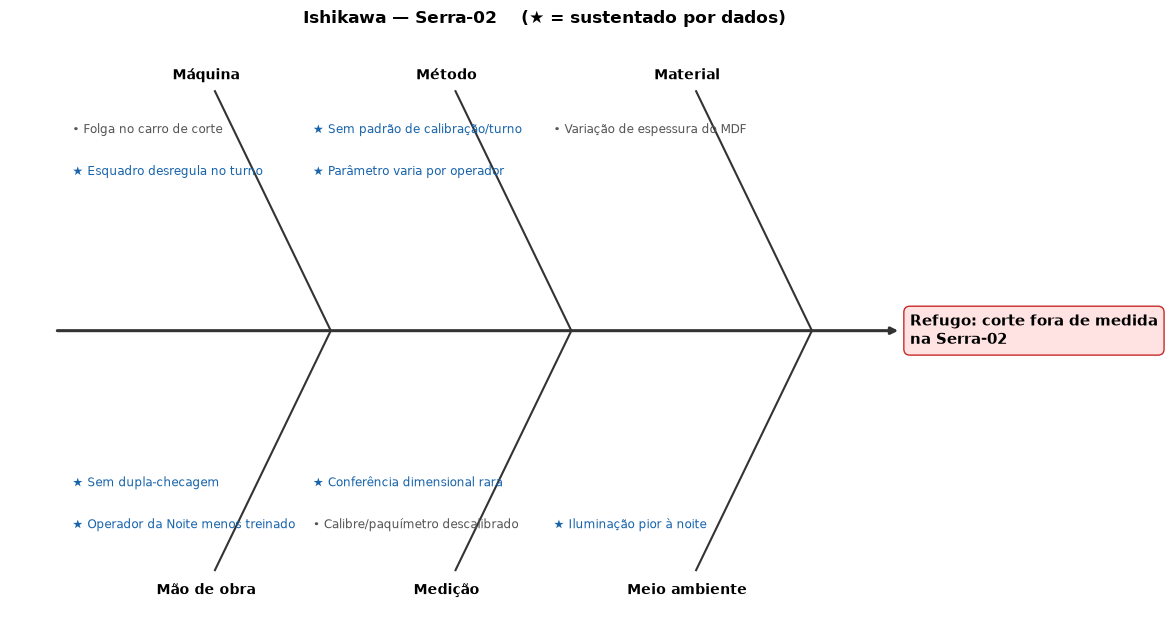

In [6]:
def ishikawa(problema, ramos, titulo):
    """Desenha um diagrama de Ishikawa simples (6 M). ★ = sustentado por dados."""
    fig, ax = plt.subplots(figsize=(12, 6.5))
    ax.axis("off")
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 10)
    # espinha central
    ax.annotate("", xy=(10, 5), xytext=(0.5, 5),
                arrowprops=dict(arrowstyle="-|>", lw=2.2, color="#333"))
    ax.text(10.1, 5, problema, va="center", ha="left", fontsize=11, weight="bold",
            bbox=dict(boxstyle="round,pad=0.4", fc="#ffe3e3", ec="#c92a2a"))
    cima = [(2.3, "Máquina"), (5.0, "Método"), (7.7, "Material")]
    baixo = [(2.3, "Mão de obra"), (5.0, "Medição"), (7.7, "Meio ambiente")]
    for x, m in cima:
        ax.plot([x, x + 1.3], [9, 5], color="#333", lw=1.5)
        ax.text(x - 0.1, 9.2, m, fontsize=10, weight="bold", ha="center")
        for i, (txt, ok) in enumerate(ramos[m]):
            cor = "#1864ab" if ok else "#555"
            mark = "★ " if ok else "• "
            ax.text(x - 1.6 + i * 0.0, 8.3 - i * 0.7, mark + txt, fontsize=8.5,
                    color=cor, ha="left")
    for x, m in baixo:
        ax.plot([x, x + 1.3], [1, 5], color="#333", lw=1.5)
        ax.text(x - 0.1, 0.6, m, fontsize=10, weight="bold", ha="center")
        for i, (txt, ok) in enumerate(ramos[m]):
            cor = "#1864ab" if ok else "#555"
            mark = "★ " if ok else "• "
            ax.text(x - 1.6, 1.7 + i * 0.7, mark + txt, fontsize=8.5, color=cor, ha="left")
    ax.set_title(titulo + "    (★ = sustentado por dados)", fontsize=12, weight="bold")
    plt.tight_layout()
    plt.show()


ramos_serra = {
    "Máquina":       [("Folga no carro de corte", False), ("Esquadro desregula no turno", True)],
    "Método":        [("Sem padrão de calibração/turno", True), ("Parâmetro varia por operador", True)],
    "Material":      [("Variação de espessura do MDF", False)],
    "Mão de obra":   [("Operador da Noite menos treinado", True), ("Sem dupla-checagem", True)],
    "Medição":       [("Calibre/paquímetro descalibrado", False), ("Conferência dimensional rara", True)],
    "Meio ambiente": [("Iluminação pior à noite", True)],
}
ishikawa("Refugo: corte fora de medida\nna Serra-02", ramos_serra,
         "Ishikawa — Serra-02")

**Leia o diagrama:** as ★ se concentram em **Método, Mão de obra, Medição e Meio
ambiente** — todas convergindo para o **turno da Noite**. *Material* e a *folga mecânica*
ficam como hipóteses não sustentadas (sem evidência no dado de 90 dias). A causa-raiz
provável é **de processo no 3º turno**, não uma peça avariada.

## 5. RCA documentada (modelo curto)

> **Problema.** Refugo crescente por corte fora de medida na Serra-02 (rampa de
> ~3 → ~12 ocorrências/semana em 90 dias).
>
> **Evidências.** (a) Tendência de subida sustentada vs baseline; (b) líder isolado do
> Pareto (~2,5× a 2ª máquina); (c) ~55% das ocorrências no turno da Noite, viés ausente no
> resto da fábrica; (d) assinatura idêntica ("corte fora de medida").
>
> **Causa-raiz provável.** Ausência de **padrão de calibração e conferência dimensional
> por turno**, agravada no 3º turno (menos supervisão/treino/iluminação). Causa de
> **processo**.
>
> **Causas afastadas.** Variação de material e folga mecânica — sem suporte na evidência
> de 90 dias (ficam para verificação física, não como causa primária).
>
> **Ação recomendada.** Padrão de calibração no início de cada turno + checagem
> dimensional obrigatória por amostragem; reforço de treino/iluminação no turno da Noite.
> (A validação da eficácia é o Encontro 3.)

## Exercício (sem resposta pronta) — faça a RCA da Coladeira-01

No Encontro 1 a **Coladeira-01** apareceu como o **problema sutil**: volume baixo, mas
recorrência regular da mesma assinatura. Agora é com você. **Na célula abaixo:**

1. Confirme a recorrência (quantas vezes, em que cadência, mesma assinatura?).
2. Conduza os **5 Porquês** da Coladeira-01, cada porquê preso a uma evidência.
3. Monte o **Ishikawa (6 M)** reutilizando a função `ishikawa(...)` e marque com ★ o que
   o dado sustenta.
4. Escreva a **RCA documentada** no modelo curto acima.

> Dica: filtre `df[df.maquina == "Coladeira-01"]` e olhe `descricao`, datas e `produto`.
> A leitura comentada está no **guia do instrutor**, não aqui.

In [7]:
# Sua RCA da Coladeira-01 aqui. Ponto de partida (sem gráfico — explore você):
cola = df[df.maquina == "Coladeira-01"].sort_values("aberto_em")
print(f"Coladeira-01: {len(cola)} ocorrências")
print(cola.descricao.value_counts().to_string())
cola[["aberto_em", "produto", "gravidade"]].head(15)

Coladeira-01: 13 ocorrências
descricao
Falha de colagem na fita de borda    13


,aberto_em,produto,gravidade
7,2025-03-05 10:16:10,Cabeceira,Médio
35,2025-03-13 03:40:57,Gaveteiro,Alto
59,2025-03-19 07:36:32,Guarda-roupa,Médio
80,2025-03-26 03:33:00,Guarda-roupa,Alto
103,2025-04-02 16:50:52,Painel de TV,Médio
130,2025-04-09 05:54:38,Mesa de jantar,Alto
156,2025-04-16 15:01:27,Mesa de jantar,Médio
188,2025-04-24 13:23:58,Cômoda,Médio
219,2025-05-02 12:29:11,Gaveteiro,Médio
252,2025-05-09 09:12:51,Guarda-roupa,Médio
